# 04 · Probabilidad y simulación

**Edición docente · 8 de octubre de 2026 · Fundamentos de Business Analytics**

**Profundización de la guía maestra · complemento, no nuevo requisito del programa FBA · 90–120 minutos.**
Construirás intuición sobre incertidumbre, probabilidad condicional, distribuciones y comportamiento
de medias muestrales. No sustituye un curso formal de Estadística.

**Cómo trabajar:** ejecuta desde la primera celda. En cada simulador formula primero una predicción,
cambia un parámetro y justifica la diferencia. Los datos son casos docentes del repositorio o
simulaciones identificadas; no permiten inferir resultados de empresas reales.

Los controles requieren JupyterLab con `ipywidgets` y un kernel activo; las salidas guardadas permiten
leer los ejemplos sin ejecutar. Las funciones también pueden llamarse directamente, con lo que
el ejercicio sigue siendo utilizable si el visor no muestra widgets.

[Guía maestra](../guia_maestra_ba.html) · [Manual científico](../material_propio/FBA_manual_cientifico.pdf)

### Antes de ejecutar

Profundización · 90–120 min orientativos.

**Objetivo:** Explicar una probabilidad condicionada y la variación de una estimación.

**Preparación:** Fracciones, porcentajes y distribuciones descritas en el módulo 02.

**Ejemplo de referencia:** Comparar probabilidad de alerta dada una condición y condición dada una alerta.

**Práctica:** Cambiar la tasa base conservando sensibilidad y especificidad; anticipar el posterior.

**Criterio de logro:** Dibujar una tabla de frecuencias y explicar el efecto de n sin confundir sesgo con precisión.

[Guía y secuencia](../guia_maestra_ba.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/FBA_manual_cientifico.html#sec-probabilidad)

In [1]:
from pathlib import Path
import sys
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "_transversal" / "datos").is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError("Abra Jupyter desde el repositorio completo o una subcarpeta.")
CURSO = RAIZ / "01_Fundamentos_Business_Analytics"
sys.path.insert(0, str(CURSO / "reproducibilidad"))
from fba_recursos import ventas, resumen_ventas, pregunta, DATOS, SEMILLA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
pd.set_option("display.max_columns", 14)
df = ventas()
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · {len(df)} transacciones")

Python 3.12.13 · pandas 3.0.6 · 180 transacciones


<a id="probabilidad"></a>

## Probabilidad y valor esperado

Para eventos, $0\leq P(A)\leq1$, $P(A^c)=1-P(A)$ y
$P(A\mid B)=P(A\cap B)/P(B)$ cuando $P(B)>0$. Independencia significa
$P(A\cap B)=P(A)P(B)$: es una propiedad más fuerte que correlación nula.
El valor esperado de una variable discreta es $E[X]=\sum_x xP(X=x)$.
Un promedio observado estima una cantidad bajo un proceso de muestreo; no es una certeza individual.

El siguiente Bayes numérico muestra el efecto de la prevalencia. El «positivo» es una alerta,
no un diagnóstico ni una recomendación de uso real: los parámetros son simulados.

In [2]:
def valor_predictivo(prevalencia=.02,sensibilidad=.90,especificidad=.95):
    numerador=prevalencia*sensibilidad
    denom=numerador+(1-prevalencia)*(1-especificidad)
    return numerador/denom if denom>0 else np.nan
print(f"P(evento | alerta) = {valor_predictivo():.3f}")
def explorar_bayes(prevalencia=.02):
    resultado=valor_predictivo(prevalencia)
    print(f"Con prevalencia {prevalencia:.1%}, el valor predictivo positivo es {resultado:.1%}.")
    return resultado
widgets.interact(explorar_bayes,prevalencia=widgets.FloatSlider(value=.02,min=.001,max=.30,step=.001));

P(evento | alerta) = 0.269


interactive(children=(FloatSlider(value=0.02, description='prevalencia', max=0.3, min=0.001, step=0.001), Outp…

<a id="distribuciones"></a>

## Modelos de distribución y sus supuestos

Bernoulli representa un evento binario; binomial suma $n$ ensayos independientes de probabilidad
constante $p$. Poisson modela conteos en una exposición definida con tasa constante bajo su modelo
simple; su igualdad media–varianza se contrasta, no se impone a cualquier dato. Uniforme asigna
la misma densidad sobre un intervalo y exponencial modela espera con tasa constante y falta de memoria.
La normal usa media $\mu$ y desviación $\sigma>0$; su soporte es toda la recta, por lo que puede
ser inadecuada para montos muy asimétricos o magnitudes no negativas cerca de cero.

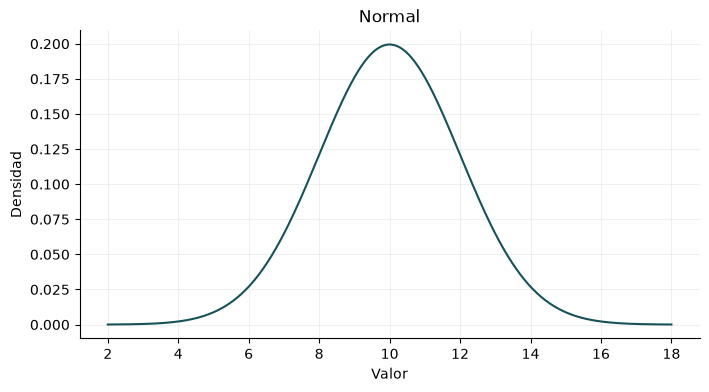

Media teórica=10.00; media de 10.000 simulaciones=10.00


interactive(children=(Dropdown(description='familia', options=('Normal', 'Binomial', 'Poisson', 'Uniforme', 'E…

In [3]:
from scipy import stats
def distribucion(familia="Normal"):
    rng=np.random.default_rng(SEMILLA)
    fig,ax=plt.subplots()
    if familia=="Binomial":
        x=np.arange(21); y=stats.binom.pmf(x,20,.2); ax.bar(x,y)
        teorica=4; muestra=rng.binomial(20,.2,10000); etiqueta="Probabilidad"
    elif familia=="Poisson":
        x=np.arange(20); y=stats.poisson.pmf(x,4); ax.bar(x,y)
        teorica=4; muestra=rng.poisson(4,10000); etiqueta="Probabilidad"
    else:
        modelos={"Normal":(stats.norm(loc=10,scale=2),np.linspace(2,18,400)),
                 "Uniforme":(stats.uniform(loc=0,scale=10),np.linspace(-1,11,400)),
                 "Exponencial":(stats.expon(scale=3),np.linspace(0,20,400))}
        dist,x=modelos[familia]; ax.plot(x,dist.pdf(x),color="#175159")
        teorica=dist.mean(); muestra=dist.rvs(size=10000,random_state=rng); etiqueta="Densidad"
    ax.set(title=familia,xlabel="Valor",ylabel=etiqueta);plt.show()
    print(f"Media teórica={teorica:.2f}; media de 10.000 simulaciones={muestra.mean():.2f}")
    return float(muestra.mean())
distribucion()
widgets.interact(distribucion,familia=["Normal","Binomial","Poisson","Uniforme","Exponencial"]);

<a id="normal"></a>

## Normal, estandarización y probabilidad de intervalo

Para $X\sim N(\mu,\sigma^2)$, $Z=(X-\mu)/\sigma$ es normal estándar y
$P(a\leq X\leq b)=\Phi((b-\mu)/\sigma)-\Phi((a-\mu)/\sigma)$.
La regla 68–95–99,7 es aproximada y se refiere a datos normales; no a cualquier distribución.
Estandarizar datos no convierte una distribución asimétrica en normal.

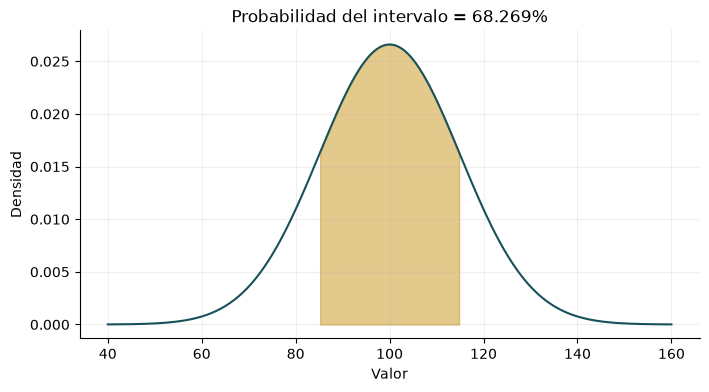

interactive(children=(FloatSlider(value=15.0, description='sigma', max=30.0, min=5.0, step=1.0), FloatSlider(v…

±1 sigma    0.682689
±2 sigma    0.954500
±3 sigma    0.997300
dtype: float64

In [4]:
def area_normal(mu=100.,sigma=15.,a=85.,b=115.):
    if sigma<=0 or a>b: raise ValueError("Se exige sigma positiva y límite inferior ≤ superior")
    prob=stats.norm.cdf(b,loc=mu,scale=sigma)-stats.norm.cdf(a,loc=mu,scale=sigma)
    xs=np.linspace(mu-4*sigma,mu+4*sigma,500); ys=stats.norm.pdf(xs,loc=mu,scale=sigma)
    fig,ax=plt.subplots(); ax.plot(xs,ys,color="#175159")
    ax.fill_between(xs,0,ys,where=(xs>=a)&(xs<=b),color="#c8951b",alpha=.5)
    ax.set(xlabel="Valor",ylabel="Densidad",title=f"Probabilidad del intervalo = {prob:.3%}");plt.show()
    return float(prob)
area_normal()
widgets.interact(area_normal,mu=widgets.fixed(100.),sigma=(5.,30.,1.),
                 a=(40.,100.,5.),b=(100.,160.,5.));
display(pd.Series({f"±{k} sigma":stats.norm.cdf(k)-stats.norm.cdf(-k) for k in [1,2,3]}))

<a id="simulacion"></a>

## Teorema central del límite y Monte Carlo

Para observaciones independientes e idénticamente distribuidas con varianza finita, la distribución
de la media estandarizada se aproxima a una normal al crecer $n$. No se afirma que los datos originales
se vuelvan normales ni que un tamaño fijo funcione para toda población. Con dependencia temporal,
colas extremas o varianza infinita las condiciones y el comportamiento cambian.

Generamos medias de una exponencial con media 3; su error estándar teórico es $3/\sqrt{n}$.
Un intervalo Monte Carlo refleja incertidumbre simulada bajo un modelo; no demuestra que el modelo
represente a una empresa. Repetir con semilla fija facilita comparar cambios de parámetros.

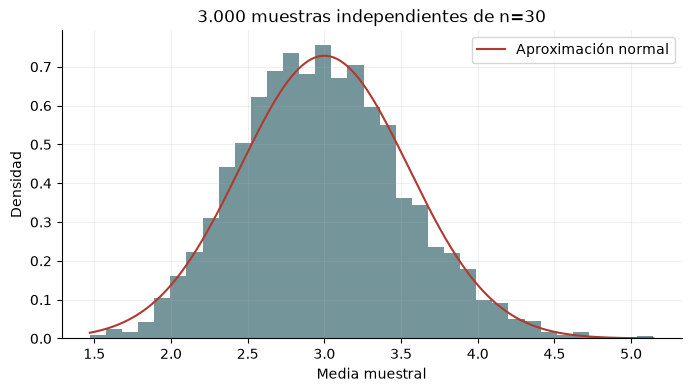

SD empírica=0.530; error estándar teórico=0.548


interactive(children=(SelectionSlider(description='n', index=3, options=(2, 5, 10, 30, 100), value=30), Output…

In [5]:
def simular_medias(n=30):
    rng=np.random.default_rng(SEMILLA)
    medias=rng.exponential(scale=3,size=(3000,n)).mean(axis=1)
    fig,ax=plt.subplots(); ax.hist(medias,bins=35,density=True,color="#175159",alpha=.6)
    x=np.linspace(medias.min(),medias.max(),300)
    ax.plot(x,stats.norm.pdf(x,loc=3,scale=3/np.sqrt(n)),color="#b03a2e",label="Aproximación normal")
    ax.set(xlabel="Media muestral",ylabel="Densidad",title=f"3.000 muestras independientes de n={n}")
    ax.legend();plt.show()
    print(f"SD empírica={medias.std(ddof=1):.3f}; error estándar teórico={3/np.sqrt(n):.3f}")
    return medias
medias=simular_medias()
widgets.interact(simular_medias,n=widgets.SelectionSlider(options=[2,5,10,30,100],value=30));

### Ejercicios con solución

1. Calcula $P(85\leq X\leq115)$ para $N(100,15^2)$: aproximadamente 0,6827.
2. Con prevalencia 2%, sensibilidad 90% y especificidad 95%, el valor predictivo positivo es
   $0,018/(0,018+0,049)\approx0,2687$. Una alta sensibilidad no basta para interpretar una alerta.
3. Al cuadruplicar $n$ bajo las condiciones anteriores, el error estándar se divide por dos.
4. Si las ventas de días consecutivos están correlacionadas, discute por qué simular días independientes
   puede subestimar incertidumbre. **Respuesta:** ignora covarianzas al calcular la varianza de la suma.

**Extensión docente:** comparar el intervalo de una media con un intervalo de predicción individual.
No tienen el mismo ancho ni responden la misma pregunta.

In [6]:
auto_04=pregunta("El teorema central del límite dice que…",
 ["Todos los datos se vuelven normales", "Bajo condiciones, la media estandarizada tiene aproximación normal",
  "Cualquier muestra de 30 garantiza normalidad"],1,
 "Se refiere a la distribución de un estadístico bajo repetición del muestreo, con condiciones.")
assert np.isclose(valor_predictivo(),.018/.067)
assert np.isclose(stats.norm.cdf(1)-stats.norm.cdf(-1),.682689492,atol=1e-8)
assert abs(medias.mean()-3)<.1
print("Comprobaciones del laboratorio 04: OK")

Comprobaciones del laboratorio 04: OK


### Referencia técnica

Las funciones se implementan con [SciPy, distribuciones estadísticas](https://docs.scipy.org/doc/scipy/reference/stats.html).
Las simulaciones y el ejemplo de decisión son originales de esta edición.